In [5]:
import os
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

In [6]:
# Check what images we have
data_path = "../data/raw/train"
class_0_path = os.path.join(data_path, "class_0")
class_1_path = os.path.join(data_path, "class_1")

class_0_files = os.listdir(class_0_path)
class_1_files = os.listdir(class_1_path)

print(f"Class 0 has {len(class_0_files)} images")
print(f"Class 1 has {len(class_1_files)} images")

Class 0 has 10 images
Class 1 has 10 images


### Load sample images
#### Reads first two images from both classes and converts from BGR to RGB
#### Prints image dimensions


In [12]:
# Load and show one image from each class
img1 = cv2.imread(os.path.join(class_0_path, class_0_files[0]))
img2 = cv2.imread(os.path.join(class_1_path, class_1_files[0]))

# Convert BGR to RGB for display
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

print(f"Image 1 shape: {img1_rgb.shape}")
print(f"Image 2 shape: {img2_rgb.shape}")

Image 1 shape: (225, 225, 3)
Image 2 shape: (182, 276, 3)


### Visualize sample images

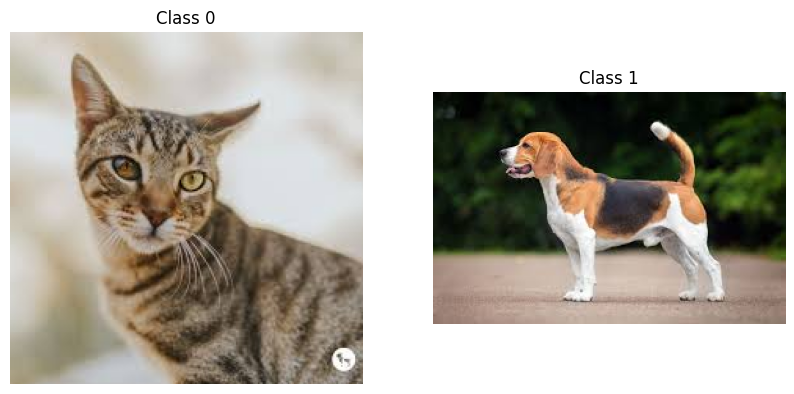

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img1_rgb)
ax1.set_title('Class 0')
ax1.axis('off')

ax2.imshow(img2_rgb)
ax2.set_title('Class 1')
ax2.axis('off')

plt.show()

### extract_hog_features converts image to grayscale, then extracts HOG features

In [15]:
# Extract HOG features from sample images
def extract_hog_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2), visualize=True)
    return features, hog_image

# Extract HOG features
hog_features_1, hog_image_1 = extract_hog_features(img1_rgb)
hog_features_2, hog_image_2 = extract_hog_features(img2_rgb)

print(f"HOG features shape: {hog_features_1.shape}")
print(f"Number of HOG features: {len(hog_features_1)}")

HOG features shape: (26244,)
Number of HOG features: 26244


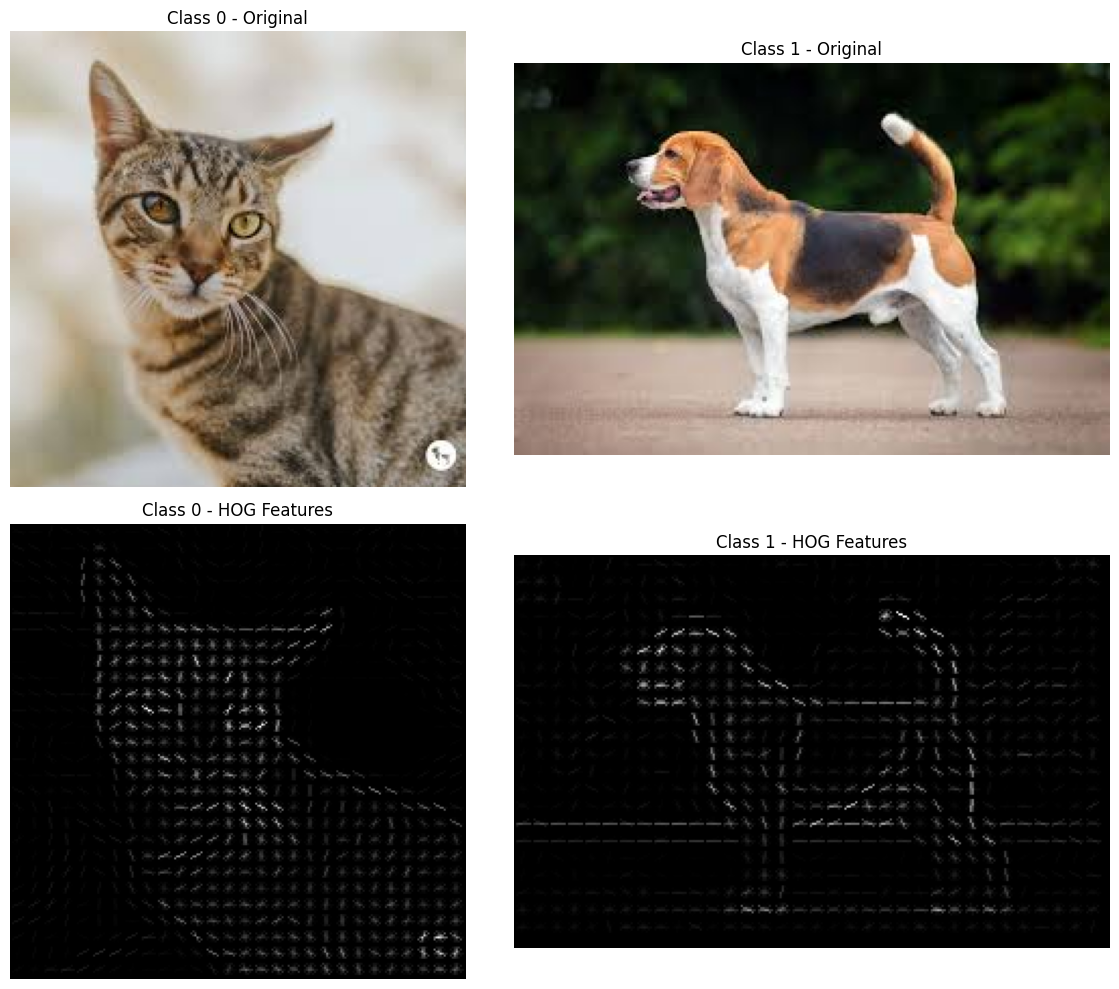

In [16]:
# Visualize HOG features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original images
axes[0, 0].imshow(img1_rgb)
axes[0, 0].set_title('Class 0 - Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img2_rgb)
axes[0, 1].set_title('Class 1 - Original')
axes[0, 1].axis('off')

# HOG visualizations
axes[1, 0].imshow(hog_image_1, cmap='gray')
axes[1, 0].set_title('Class 0 - HOG Features')
axes[1, 0].axis('off')

axes[1, 1].imshow(hog_image_2, cmap='gray')
axes[1, 1].set_title('Class 1 - HOG Features')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()